**INDIA AIR QUALITY DATA ANALYSIS**

This project analyzes air pollution levels across different locations in India using pollutants such as SO2, NO2, RSPM, and SPM to identify pollution patterns and environmental trends.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [67]:

df = pd.read_csv('data.csv', encoding='latin1', low_memory=False)


df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


**Data Undertsanding**

Structure and basic information regarding the data is given here

In [68]:

df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


**Data Cleaning**

Cleansing columns to maintain data integrity and prevent mistakes.

In [69]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

**TOP 10 CITIES WITH THE HIGHEST S02**

In [70]:
df.sort_values(by='so2', ascending=False).head(10)




,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
353477,71,5/2/2011,Tamil Nadu,Chennai,Tamilnadu State Pollution Control Board,Industrial Area,909.0,22.0,87.0,NaN,"Govt. High School, Manali, Chennai.",NaN,2011-02-05
233803,165,25/06/2012,Maharashtra,Nagpur,National Environmental Engineering Research In...,Industrial Area,597.0,19.0,143.0,NaN,"MIDC Industrial Area, MIDC Office, Hingna,Nagpur",NaN,2012-06-25
429531,662,2/4/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,498.0,10.0,72.0,NaN,"Raniganj, Raniganj",NaN,2011-04-02
429525,662,1/11/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,492.0,10.0,79.0,NaN,"Raniganj, Raniganj",NaN,2011-11-01
429625,662,27/12/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,482.0,13.0,106.0,NaN,"Raniganj, Raniganj",NaN,2011-12-27
429524,662,1/9/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,421.0,11.0,76.0,NaN,"Raniganj, Raniganj",NaN,2011-09-01
429529,662,29/01/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,407.0,10.0,75.0,NaN,"Raniganj, Raniganj",NaN,2011-01-29
429522,662,1/5/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,405.0,11.0,73.0,NaN,"Raniganj, Raniganj",NaN,2011-05-01
429609,662,11/5/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,393.0,12.0,72.0,NaN,"Raniganj, Raniganj",NaN,2011-05-11
429539,662,3/5/2011,West Bengal,Raniganj,West Bengal State Pollution Control Board,Industrial Area,380.0,10.0,69.0,NaN,"Raniganj, Raniganj",NaN,2011-05-03


**COUNT OF AREA CATEGORIES**

In [71]:
df['type'].value_counts()

,count
type,
"Residential, Rural and other Areas",179014
Industrial Area,96091
Residential and others,86791
Industrial Areas,51747
Sensitive Area,8980
Sensitive Areas,5536
RIRUO,1304
Sensitive,495
Industrial,233


AVERAGE  $NO_2$ LEVELS PER STATE

In [72]:
df.groupby('state')['no2'].mean()

,no2
state,
Andhra Pradesh,21.704451
Arunachal Pradesh,5.469697
Assam,14.793691
Bihar,36.575525
Chandigarh,18.619404
Chhattisgarh,24.815961
Dadra & Nagar Haveli,18.293959
Daman & Diu,16.168926
Delhi,53.489147


**DISTRIBUTION OF STATION TYPES**

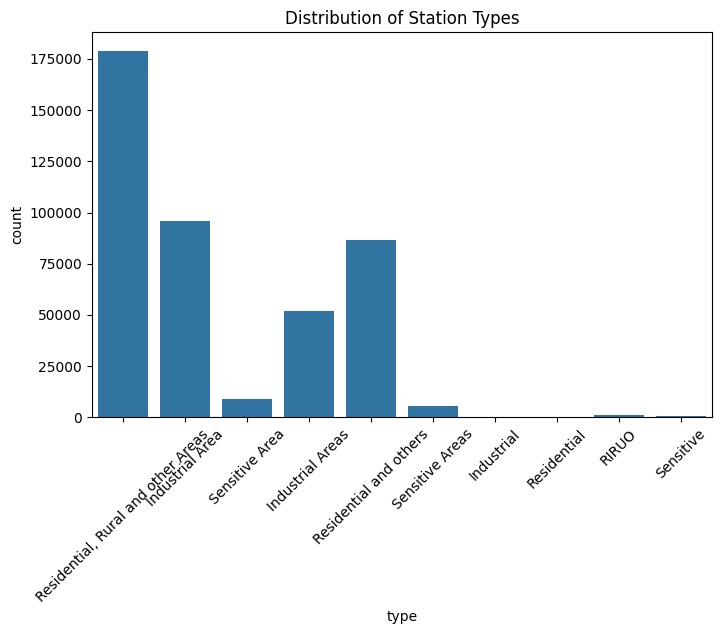

In [73]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='type')

plt.title("Distribution of Station Types")

plt.xticks(rotation=45)

plt.show()

**CORRELATION HEATMAP**

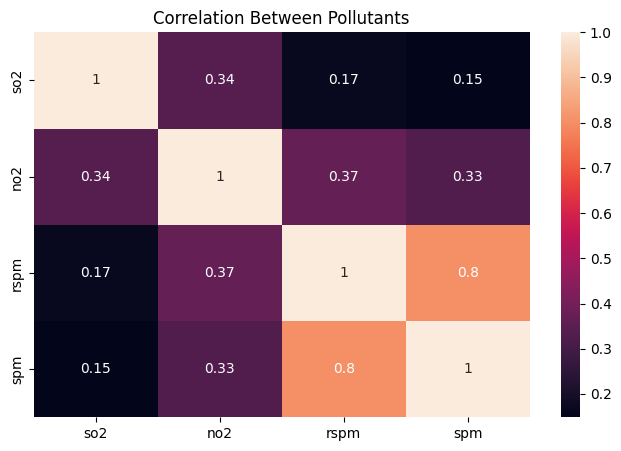

In [74]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['so2','no2','rspm','spm']].corr(),
    annot=True
)

plt.title("Correlation Between Pollutants")

plt.show()

**DISTRIBUTION OF NITROGEN DIOXIDE LEVELS**

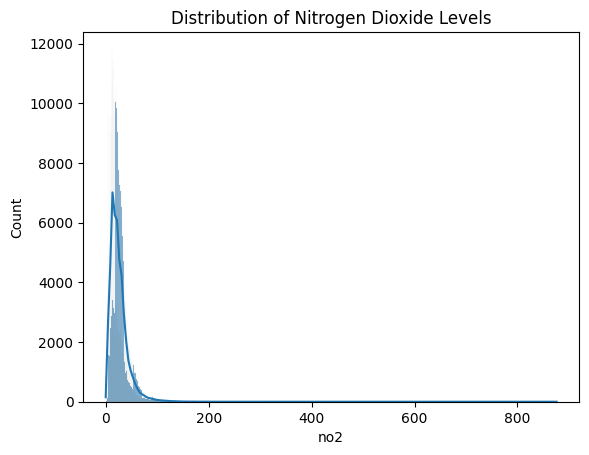

In [75]:
sns.histplot(df['no2'], kde=True)
plt.title('Distribution of Nitrogen Dioxide Levels')
plt.show()

**CONCLUSION**

 The data shows that industrial areas have significantly higher $NO_2$ levels compared to residential areas. Additionally, Maharashtra appears most frequently in this specific dataset